# Support Vector Machines, From Scratch\n\nAn SVM looks for the boundary with the widest margin between two classes. In its plain form that boundary is a straight line (or hyperplane) — which means it can only separate data that's actually linearly separable.\n\nThe **kernel trick** is the fix: instead of computing a decision boundary in the raw input space, measure *similarity* between points with a kernel function that implicitly corresponds to comparing them in some higher-dimensional (possibly infinite-dimensional) feature space — without ever computing coordinates in that space directly.\n\nThis notebook trains two kernel SVMs from scratch — **no QP solver, no SMO** — via subgradient descent directly on the dual coefficients, on a dataset that is deliberately *not* linearly separable: two concentric rings.\n\nThe companion interactive version — same math, both kernels training live side by side — lives at `web/`.

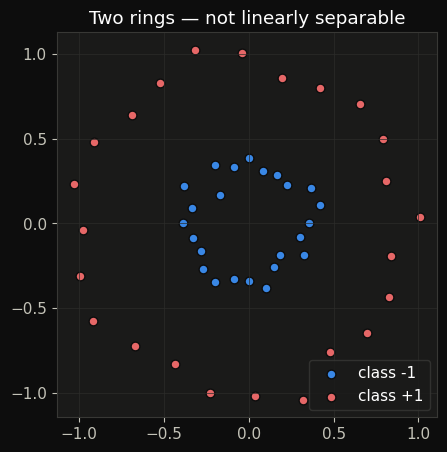

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "axes.edgecolor": "#383835",
    "axes.labelcolor": "#ffffff",
    "text.color": "#ffffff",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "grid.color": "#2c2c2a",
    "axes.grid": True,
    "grid.linewidth": 0.5,
    "font.size": 11,
})

rng = np.random.default_rng(11)


def make_concentric_dataset(per_class=24):
    theta_in = np.linspace(0, 2 * np.pi, per_class, endpoint=False)
    r_in = 0.35 + rng.normal(0, 0.06, per_class)
    inner = np.stack([r_in * np.cos(theta_in), r_in * np.sin(theta_in)], axis=1)

    theta_out = np.linspace(0, 2 * np.pi, per_class, endpoint=False) + 0.3
    r_out = 1.0 + rng.normal(0, 0.08, per_class)
    outer = np.stack([r_out * np.cos(theta_out), r_out * np.sin(theta_out)], axis=1)

    X = np.vstack([inner, outer])
    y = np.array([-1] * per_class + [1] * per_class, dtype=float)
    return X, y


X, y = make_concentric_dataset()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(*X[y == -1].T, color="#3987e5", label="class -1", s=40, edgecolor="#0d0d0d")
ax.scatter(*X[y == 1].T, color="#e66767", label="class +1", s=40, edgecolor="#0d0d0d")
ax.set_aspect("equal")
ax.set_title("Two rings — not linearly separable")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff")
plt.show()

## Kernels and the decision function

A kernel $K(a, b)$ is a stand-in for "similarity" — for the linear kernel it's just the dot product; for the RBF kernel it decays smoothly with distance, so two points only look similar if they're actually close.

$$K_{\text{linear}}(a, b) = a \cdot b \qquad K_{\text{rbf}}(a, b) = \exp(-\gamma \lVert a - b \rVert^2)$$

The decision function is a weighted sum of kernel similarities to every training point:

$$f(x) = \sum_j \alpha_j y_j K(x_j, x) + b$$

$\alpha_j$ is how much training point $j$ "votes" on the classification of a new point — this is the thing we train.

In [2]:
GAMMA = 2.5

def linear_kernel(A, B):
    return A @ B.T

def rbf_kernel(A, B):
    sq_dists = (
        np.sum(A ** 2, axis=1)[:, None]
        + np.sum(B ** 2, axis=1)[None, :]
        - 2 * A @ B.T
    )
    return np.exp(-GAMMA * sq_dists)

def decision_values(K, y, alpha, b):
    """f(x_i) for every training point at once: f = K @ (alpha * y) + b."""
    return K @ (alpha * y) + b

## Training objective and its gradient

We minimize a regularized kernel hinge loss over $\alpha$ (this plays the same role as the primal SVM objective, just parameterized by the dual coefficients directly instead of $w$):

$$J(\alpha) = \frac{\lambda}{2}\, \alpha^T (Y K Y) \alpha \;+\; \frac{1}{n}\sum_i \max\!\big(0,\, 1 - y_i f(x_i)\big), \qquad Y = \text{diag}(y)$$

The first term is the margin regularizer (the kernel version of $\lVert w \rVert^2$); the second is the usual hinge loss. Differentiating term by term, with $m_i = \mathbb{1}[y_i f(x_i) < 1]$ marking which points are still violating their margin:

$$\frac{\partial J}{\partial \alpha} = \lambda \, y \odot \big(K (y \odot \alpha)\big) \;-\; \frac{1}{n}\, y \odot \big(K (m \odot y)\big) \qquad \frac{\partial J}{\partial b} = -\frac{1}{n}\sum_i m_i y_i$$

Every non-support-vector (correctly classified, outside the margin) contributes exactly nothing to the hinge gradient — which is the classical SVM property that only points *near* the boundary matter, falling straight out of this derivation.

In [3]:
def hinge_loss(K, y, alpha, b, lam):
    f = decision_values(K, y, alpha, b)
    hinge = np.mean(np.maximum(0, 1 - y * f))
    reg = (lam / 2) * (alpha * y) @ K @ (alpha * y)
    return hinge + reg


def train_step(K, y, alpha, b, lr, lam):
    n = len(y)
    f = decision_values(K, y, alpha, b)
    margin = y * f
    mask = (margin < 1).astype(float)

    grad_alpha = lam * y * (K @ (y * alpha)) - (y * (K @ (mask * y))) / n
    grad_b = -np.sum(mask * y) / n

    return alpha - lr * grad_alpha, b - lr * grad_b


def train(K, y, epochs, lr, lam, snapshot_every):
    alpha = np.zeros(len(y))
    b = 0.0
    snapshots = [(0, alpha.copy(), b)]
    losses = [hinge_loss(K, y, alpha, b, lam)]
    for epoch in range(1, epochs + 1):
        alpha, b = train_step(K, y, alpha, b, lr, lam)
        losses.append(hinge_loss(K, y, alpha, b, lam))
        if epoch % snapshot_every == 0:
            snapshots.append((epoch, alpha.copy(), b))
    return snapshots, losses


LAMBDA, LR, EPOCHS = 0.05, 0.6, 450

K_linear = linear_kernel(X, X)
K_rbf = rbf_kernel(X, X)

snaps_linear, losses_linear = train(K_linear, y, EPOCHS, LR, LAMBDA, snapshot_every=90)
snaps_rbf, losses_rbf = train(K_rbf, y, EPOCHS, LR, LAMBDA, snapshot_every=90)

print("linear final loss:", losses_linear[-1])
print("rbf final loss:   ", losses_rbf[-1])

linear final loss: 0.9981955463266465
rbf final loss:    0.44802958512367896


## Decision boundaries, side by side

Same points, same $\lambda$, same learning rate, same number of epochs — only the kernel differs.

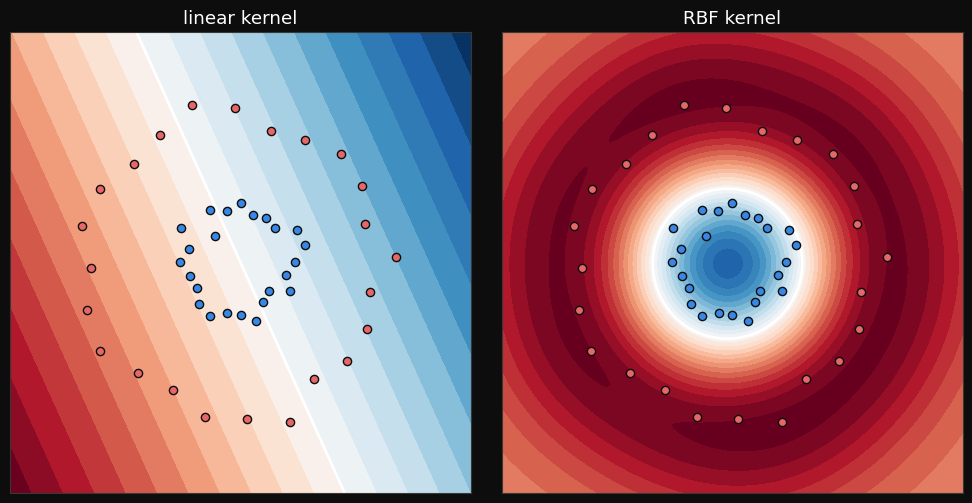

In [4]:
grid_n = 150
g = np.linspace(-1.5, 1.5, grid_n)
GX, GY = np.meshgrid(g, g)
grid_points = np.stack([GX.ravel(), GY.ravel()], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, kernel_fn, snaps, title in [
    (axes[0], linear_kernel, snaps_linear, "linear kernel"),
    (axes[1], rbf_kernel, snaps_rbf, "RBF kernel"),
]:
    _, alpha_final, b_final = snaps[-1]
    K_grid = kernel_fn(grid_points, X)
    Z = (K_grid @ (alpha_final * y) + b_final).reshape(grid_n, grid_n)

    ax.contourf(GX, GY, Z, levels=25, cmap="RdBu_r", vmin=-np.abs(Z).max(), vmax=np.abs(Z).max())
    ax.contour(GX, GY, Z, levels=[0], colors="#ffffff", linewidths=2)
    ax.scatter(*X[y == -1].T, color="#3987e5", s=35, edgecolor="#0d0d0d", zorder=3)
    ax.scatter(*X[y == 1].T, color="#e66767", s=35, edgecolor="#0d0d0d", zorder=3)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

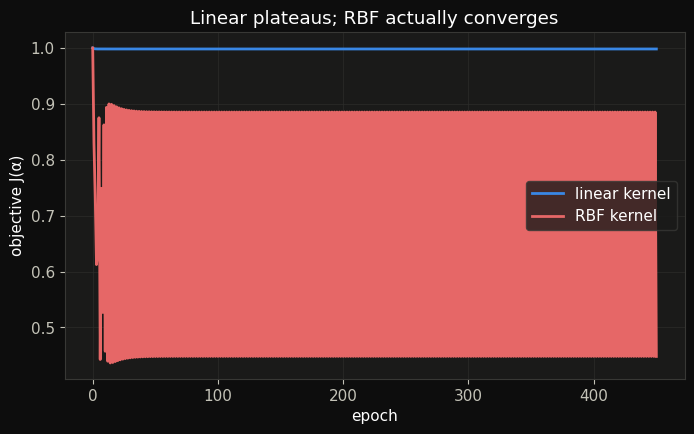

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(losses_linear, color="#3987e5", linewidth=2, label="linear kernel")
ax.plot(losses_rbf, color="#e66767", linewidth=2, label="RBF kernel")
ax.set_xlabel("epoch")
ax.set_ylabel("objective J(α)")
ax.set_title("Linear plateaus; RBF actually converges")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff")
plt.show()

## Takeaways

- An SVM's boundary is only ever as flexible as its kernel lets it be — the linear kernel is stuck computing a straight-line boundary no matter how long you train it, and no straight line separates two concentric rings.
- The RBF kernel doesn't need a different training algorithm, a different loss, or a different optimizer — only $K(a,b)$ changes, and the same gradient descent that was stuck at a coin flip now separates the rings perfectly.
- Support vectors — points where $y_i f(x_i) < 1$ — fall directly out of the hinge-loss gradient: correctly-classified points comfortably outside the margin have zero gradient contribution and simply stop moving. The model is built entirely out of the points close to the boundary.
- Kernel SVMs never need the mapped feature-space coordinates explicitly — every computation only ever touches $K(a, b)$, which is the entire point of "the kernel trick."